## Regression mit neuem Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
import os
print(os.getcwd())

/Users/elizavetalozovskaa/PycharmProjects/SEP-Project-/notebooks


In [18]:
film_daten = pd.read_csv('../Dataset/film_level_clean.csv')
print(film_daten.head())

                        id  joy_mean  anger_mean  fear_mean  sadness_mean  \
0            009_re_cyborg  0.177228    0.052952   0.107659      0.112802   
1                    1-day  0.134815    0.021872   0.017419      0.090791   
2                       10  0.386193    0.010750   0.051379      0.079324   
3     1000013_12_angry_men  0.246861    0.064991   0.030424      0.041336   
4  10000604-porgy_and_bess  0.328769    0.019606   0.036509      0.081594   

   surprise_mean  disgust_mean  neutral_mean  neutral_std  num_reviews  ...  \
0       0.057184      0.226962      0.265214     0.265032           13  ...   
1       0.020774      0.162349      0.551980     0.317377           15  ...   
2       0.138984      0.158981      0.174390     0.197188           16  ...   
3       0.075903      0.050842      0.489642     0.334757           46  ...   
4       0.031143      0.058021      0.444357     0.315460           46  ...   

   Mystery & thriller  Nature  Romance Sci-fi  Short  Sports  

In [19]:
film_daten.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19486 entries, 0 to 19485
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  19486 non-null  object 
 1   joy_mean            19486 non-null  float64
 2   anger_mean          19486 non-null  float64
 3   fear_mean           19486 non-null  float64
 4   sadness_mean        19486 non-null  float64
 5   surprise_mean       19486 non-null  float64
 6   disgust_mean        19486 non-null  float64
 7   neutral_mean        19486 non-null  float64
 8   neutral_std         19486 non-null  float64
 9   num_reviews         19486 non-null  int64  
 10  share_high          19486 non-null  float64
 11  share_low           19486 non-null  float64
 12  share_medium        19486 non-null  float64
 13  title               19486 non-null  object 
 14  audienceScore       19486 non-null  float64
 15  tomatoMeter         19486 non-null  float64
 16  runt

In [20]:
film_daten.isnull().sum()

id                       0
joy_mean                 0
anger_mean               0
fear_mean                0
sadness_mean             0
surprise_mean            0
disgust_mean             0
neutral_mean             0
neutral_std              0
num_reviews              0
share_high               0
share_low                0
share_medium             0
title                    0
audienceScore            0
tomatoMeter              0
runtimeMinutes           0
genre                    1
originalLanguage       117
director                28
writer                2495
Action                   0
Adventure                0
Animation                0
Anime                    0
Biography                0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Foreign                  0
History                  0
Holiday                  0
Horror                   0
Kids & family            0
Lgbtq+                   0
M

In [21]:
film_daten['tomatoMeter'].describe()

count    19486.000000
mean        66.099405
std         26.899609
min          0.000000
25%         47.000000
50%         73.000000
75%         89.000000
max        100.000000
Name: tomatoMeter, dtype: float64

<Axes: xlabel='tomatoMeter', ylabel='Count'>

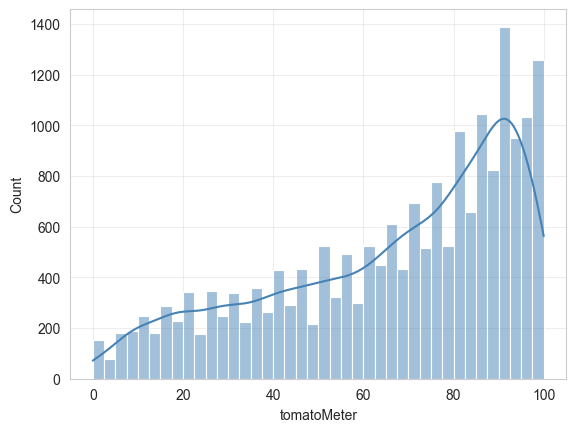

In [22]:
sns.set_style('whitegrid')
sns.histplot(data=film_daten, x='tomatoMeter', bins=40, kde=True, color='steelblue')

<Axes: >

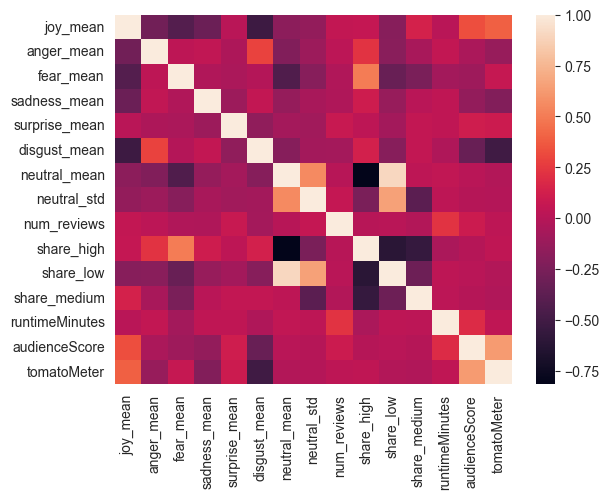

In [23]:
numerische_spalten = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean', 'neutral_mean', 'neutral_std',
    'num_reviews', 'share_high', 'share_low', 'share_medium',
    'runtimeMinutes', 'audienceScore', 'tomatoMeter'
]
sns.heatmap(film_daten[numerische_spalten].corr())

In [24]:
film_daten['runtimeMinutes'] = film_daten['runtimeMinutes'].fillna(film_daten['runtimeMinutes'].median())
film_daten['ist_englisch'] = (film_daten['originalLanguage'].str.contains('English', na=False)).astype(int)

print('Fehlende Werte nach der Bereinigung:')
print(film_daten.isnull().sum())

Fehlende Werte nach der Bereinigung:
id                       0
joy_mean                 0
anger_mean               0
fear_mean                0
sadness_mean             0
surprise_mean            0
disgust_mean             0
neutral_mean             0
neutral_std              0
num_reviews              0
share_high               0
share_low                0
share_medium             0
title                    0
audienceScore            0
tomatoMeter              0
runtimeMinutes           0
genre                    1
originalLanguage       117
director                28
writer                2495
Action                   0
Adventure                0
Animation                0
Anime                    0
Biography                0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Foreign                  0
History                  0
Holiday                  0
Horror                   0
Kids & family     

In [25]:
merged = pd.read_csv('../Dataset/merged_clean.csv')
print(f'Geladene Reviews: {len(merged)}')
print(f'Einzigartige Filme: {merged["id"].nunique()}')

Geladene Reviews: 1318419
Einzigartige Filme: 66333


In [26]:
zusatz_merkmale = merged[['id', 'rating', 'ratingContents', 'boxOffice', 'releaseDateTheaters']].drop_duplicates(subset='id')
print(f'Filme mit zusaetzlichen Merkmalen: {zusatz_merkmale.shape[0]}')
print(zusatz_merkmale.head())

Filme mit zusaetzlichen Merkmalen: 66333
                                   id rating ratingContents boxOffice  \
0                             beavers    NaN            NaN       NaN   
1                          blood_mask    NaN            NaN       NaN   
2   city_hunter_shinjuku_private_eyes    NaN            NaN       NaN   
4                  dangerous_men_2015    NaN            NaN       NaN   
14               small_town_wisconsin    NaN            NaN       NaN   

   releaseDateTheaters  
0                  NaN  
1                  NaN  
2                  NaN  
4                  NaN  
14          2022-06-03  


In [27]:
film_daten = film_daten.merge(zusatz_merkmale, on='id', how='left')
print(f'Datensatz nach Zusammenfuehrung: {film_daten.shape}')
print('Fehlende Werte in den neuen Merkmalen:')
print(film_daten[['rating', 'ratingContents', 'boxOffice', 'releaseDateTheaters']].isnull().sum())

Datensatz nach Zusammenfuehrung: (19486, 54)
Fehlende Werte in den neuen Merkmalen:
rating                 11518
ratingContents         11518
boxOffice               8631
releaseDateTheaters     5113
dtype: int64


In [28]:
film_daten['rating'] = film_daten['rating'].fillna('Unbekannt')
print('Fehlende Werte nach der Bereinigung:')
print(film_daten[['rating', 'ratingContents', 'boxOffice', 'releaseDateTheaters']].isnull().sum())

Fehlende Werte nach der Bereinigung:
rating                     0
ratingContents         11518
boxOffice               8631
releaseDateTheaters     5113
dtype: int64


In [29]:
def parse_box_office(wert):
    if pd.isna(wert):
        return np.nan
    wert = wert.replace('$', '').strip()
    if wert.endswith('K'):
        return float(wert[:-1]) * 1_000
    elif wert.endswith('M'):
        return float(wert[:-1]) * 1_000_000
    elif wert.endswith('B'):
        return float(wert[:-1]) * 1_000_000_000
    else:
        return float(wert)

film_daten['boxOffice_num'] = film_daten['boxOffice'].apply(parse_box_office)
print(film_daten[['boxOffice', 'boxOffice_num']].head(10))

  boxOffice  boxOffice_num
0       NaN            NaN
1       NaN            NaN
2       NaN            NaN
3       NaN            NaN
4       NaN            NaN
5       NaN            NaN
6       NaN            NaN
7    $94.8M     94800000.0
8       NaN            NaN
9       NaN            NaN


In [30]:
film_daten['releaseYear_theaters'] = pd.to_datetime(
    film_daten['releaseDateTheaters'], errors='coerce'
).dt.year
print(film_daten[['releaseDateTheaters', 'releaseYear_theaters']].head(10))

  releaseDateTheaters  releaseYear_theaters
0                 NaN                   NaN
1                 NaN                   NaN
2          1979-10-05                1979.0
3          1957-04-20                1957.0
4          1959-06-24                1959.0
5          1927-08-20                1927.0
6          1954-12-23                1954.0
7          2008-03-07                2008.0
8          2015-07-10                2015.0
9          1935-06-18                1935.0


In [31]:
film_daten['releaseMonth_theaters'] = pd.to_datetime(
    film_daten['releaseDateTheaters'], errors='coerce'
).dt.month
print(film_daten[['releaseDateTheaters', 'releaseMonth_theaters']].head(10))

  releaseDateTheaters  releaseMonth_theaters
0                 NaN                    NaN
1                 NaN                    NaN
2          1979-10-05                   10.0
3          1957-04-20                    4.0
4          1959-06-24                    6.0
5          1927-08-20                    8.0
6          1954-12-23                   12.0
7          2008-03-07                    3.0
8          2015-07-10                    7.0
9          1935-06-18                    6.0


In [32]:
def zaehle_rating_gruende(text):
    if pd.isna(text):
        return 0
    gruende = text.split(',')
    return len(gruende)

film_daten['ratingContents_anzahl'] = film_daten['ratingContents'].apply(zaehle_rating_gruende)
print(film_daten[['ratingContents', 'ratingContents_anzahl']].head(10))

                                      ratingContents  ratingContents_anzahl
0                                                NaN                      0
1                                                NaN                      0
2                                                NaN                      0
3                                                NaN                      0
4                                                NaN                      0
5                                                NaN                      0
6                                                NaN                      0
7        ['Violence', 'Sequences of Intense Action']                      2
8  ['Some Strong Sexual Content', 'Brief Graphic ...                      4
9                                                NaN                      0


In [33]:
rating_dummies = pd.get_dummies(film_daten['rating'], prefix='rating')
film_daten = pd.concat([film_daten, rating_dummies], axis=1)
print(f'Anzahl rating-Spalten: {rating_dummies.shape[1]}')
print(rating_dummies.columns.tolist())

Anzahl rating-Spalten: 9
['rating_NC-17', 'rating_PG', 'rating_PG-13', 'rating_R', 'rating_TV14', 'rating_TVMA', 'rating_TVPG', 'rating_TVY7', 'rating_Unbekannt']


In [34]:
film_daten['genre_count'] = film_daten['genre'].fillna('').apply(
    lambda x: len([g.strip() for g in x.split(',') if g.strip() != ''])
)
print(f'Form des Datensatzes: {film_daten.shape}')
print(film_daten[['title', 'genre', 'genre_count']].head())

Form des Datensatzes: (19486, 68)
            title                      genre  genre_count
0  009 Re: Cyborg  Action, Sci-fi, Animation            3
1           1 Day                      Drama            1
2              10            Romance, Comedy            2
3    12 Angry Men                      Drama            1
4  Porgy and Bess    Drama, Musical, Romance            3


In [35]:
genre_spalten = ['Action', 'Adventure', 'Animation', 'Anime', 'Biography',
                 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
                 'Foreign', 'History', 'Holiday', 'Horror', 'Kids & family',
                 'Lgbtq+', 'Music', 'Musical', 'Mystery & thriller', 'Nature',
                 'Romance', 'Sci-fi', 'Short', 'Sports', 'Sports & fitness',
                 'Stand-up', 'War', 'Western']

rating_spalten = [col for col in film_daten.columns if col.startswith('rating_')]

feature_spalten_tomato = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean',
    'neutral_std',
    'share_high', 'share_low',
    'num_reviews', 'runtimeMinutes', 'ist_englisch',
    'genre_count', 'releaseYear_theaters', 'releaseMonth_theaters',
    'boxOffice_num', 'ratingContents_anzahl'
] + genre_spalten + rating_spalten

X_tomato = film_daten[feature_spalten_tomato]
y_tomato = film_daten['tomatoMeter']

print(f'Anzahl Features: {len(feature_spalten_tomato)}')
print(f'Anzahl Datenpunkte: {X_tomato.shape[0]}')

Anzahl Features: 54
Anzahl Datenpunkte: 19486


In [36]:
for spalte in ['boxOffice_num', 'releaseYear_theaters', 'releaseMonth_theaters', 'ratingContents_anzahl']:
    film_daten[spalte] = film_daten[spalte].fillna(film_daten[spalte].median())

X_tomato = film_daten[feature_spalten_tomato]
print('Fehlende Werte nach der Bereinigung:')
print(X_tomato.isnull().sum().sum())

Fehlende Werte nach der Bereinigung:
0


In [37]:
X_train_tomato, X_test_tomato, y_train_tomato, y_test_tomato = train_test_split(
    X_tomato, y_tomato, test_size=0.20, random_state=101
)
print(f'Trainingsdaten: {X_train_tomato.shape[0]} Filme')
print(f'Testdaten: {X_test_tomato.shape[0]} Filme')

Trainingsdaten: 15588 Filme
Testdaten: 3898 Filme


In [38]:
X_train_tomato_skaliert = X_train_tomato.copy()
X_test_tomato_skaliert = X_test_tomato.copy()

for column in X_train_tomato_skaliert.columns:
    mean_value = X_train_tomato_skaliert[column].mean()
    std_value = X_train_tomato_skaliert[column].std()
    X_train_tomato_skaliert[column] = (X_train_tomato_skaliert[column] - mean_value) / std_value
    X_test_tomato_skaliert[column] = (X_test_tomato_skaliert[column] - mean_value) / std_value

X_train_tomato_skaliert = X_train_tomato_skaliert.replace([float("inf"), float("-inf")], 0).fillna(0)
X_test_tomato_skaliert = X_test_tomato_skaliert.replace([float("inf"), float("-inf")], 0).fillna(0)

In [39]:
X_train_tomato_skaliert.runtimeMinutes.mean()

np.float64(1.878006204344119e-16)

In [40]:
X_train_tomato_skaliert.runtimeMinutes.std()

np.float64(1.0)

In [41]:
clf_tomato = linear_model.LinearRegression()
clf_tomato.fit(X_train_tomato_skaliert, y_train_tomato)

LinearRegression()

In [42]:
y_vorhersage_lr_tomato = clf_tomato.predict(X_test_tomato_skaliert)

In [43]:
rmse_lr_tomato = np.sqrt(mean_squared_error(y_test_tomato, y_vorhersage_lr_tomato))
mae_lr_tomato = mean_absolute_error(y_test_tomato, y_vorhersage_lr_tomato)
r2_lr_tomato = r2_score(y_test_tomato, y_vorhersage_lr_tomato)

print('=== Lineare Regression - tomatoMeter ===')
print(f'RMSE: {rmse_lr_tomato:.2f}')
print(f'MAE:  {mae_lr_tomato:.2f}')
print(f'R²:   {r2_lr_tomato:.4f}')

=== Lineare Regression - tomatoMeter ===
RMSE: 17.33
MAE:  13.86
R²:   0.5889


In [44]:
wald_modell_tomato = RandomForestRegressor(n_estimators=100, random_state=101)
wald_modell_tomato.fit(X_train_tomato, y_train_tomato)

RandomForestRegressor(random_state=101)

In [45]:
y_vorhersage_rf_tomato = wald_modell_tomato.predict(X_test_tomato)

In [46]:
rmse_rf_tomato = np.sqrt(mean_squared_error(y_test_tomato, y_vorhersage_rf_tomato))
mae_rf_tomato = mean_absolute_error(y_test_tomato, y_vorhersage_rf_tomato)
r2_rf_tomato = r2_score(y_test_tomato, y_vorhersage_rf_tomato)

print('=== Random Forest - tomatoMeter ===')
print(f'RMSE: {rmse_rf_tomato:.2f}')
print(f'MAE:  {mae_rf_tomato:.2f}')
print(f'R²:   {r2_rf_tomato:.4f}')

=== Random Forest - tomatoMeter ===
RMSE: 16.19
MAE:  12.51
R²:   0.6410


In [47]:
y_vorhersage_rf_tomato_train = wald_modell_tomato.predict(X_train_tomato)
r2_rf_tomato_train = r2_score(y_train_tomato, y_vorhersage_rf_tomato_train)

print(f'R² (Train): {r2_rf_tomato_train:.4f}')
print(f'R² (Test):  {r2_rf_tomato:.4f}')
print(f'Differenz:  {r2_rf_tomato_train - r2_rf_tomato:.4f}')

R² (Train): 0.9495
R² (Test):  0.6410
Differenz:  0.3086


In [48]:
vergleich = pd.DataFrame({
    'Modell': ['Lineare Regression', 'Random Forest'],
    'RMSE': [rmse_lr_tomato, rmse_rf_tomato],
    'MAE':  [mae_lr_tomato, mae_rf_tomato],
    'R²':   [r2_lr_tomato, r2_rf_tomato]
})
print('=== Vergleich der Modelle ===')
print(vergleich.to_string(index=False))

=== Vergleich der Modelle ===
            Modell      RMSE       MAE       R²
Lineare Regression 17.328084 13.863160 0.588865
     Random Forest 16.192970 12.509279 0.640965


In [49]:
koeffizienten_tomato = pd.DataFrame({
    'Merkmal': feature_spalten_tomato,
    'Koeffizient': clf_tomato.coef_
})
koeffizienten_tomato = koeffizienten_tomato.reindex(
    koeffizienten_tomato['Koeffizient'].abs().sort_values(ascending=False).index
)
print('Einfluss der Merkmale (Lineare Regression - tomatoMeter)')
print(koeffizienten_tomato.head(15).to_string(index=False))

Einfluss der Merkmale (Lineare Regression - tomatoMeter)
             Merkmal  Koeffizient
        disgust_mean    -7.767505
            joy_mean     7.661368
         Documentary     7.407939
         num_reviews     7.208430
           fear_mean     5.242605
        ist_englisch    -4.298456
releaseYear_theaters    -4.052016
               Drama     3.970650
    rating_Unbekannt     3.497240
        rating_PG-13    -3.299220
        sadness_mean    -2.989736
              Comedy    -2.618895
       Kids & family    -2.349713
              Horror    -2.169955
              Action    -1.921075


<Axes: xlabel='Koeffizient', ylabel='Merkmal'>

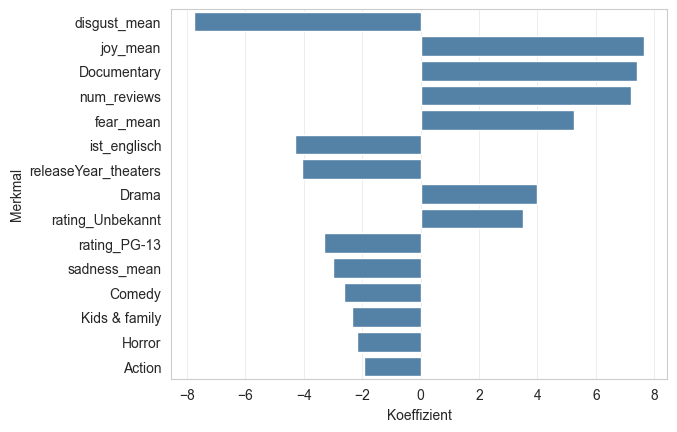

In [50]:
sns.set_style('whitegrid')
sns.barplot(data=koeffizienten_tomato.head(15), x='Koeffizient', y='Merkmal', color='steelblue')